In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('../original_datasets/weather_data.csv')

print(df.info())
print(df.describe())
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 11149 entries, 0 to 11148
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                11149 non-null  str    
 1   City Name           11149 non-null  str    
 2   temp                10974 non-null  str    
 3   Temp Unit           8411 non-null   str    
 4   humidity_%          10891 non-null  str    
 5   Precipitation (mm)  11149 non-null  float64
 6   wind_speed_kmph     11030 non-null  str    
 7   Visibility_KM       11149 non-null  float64
 8   condition           11149 non-null  str    
 9   storm_alert         10643 non-null  str    
dtypes: float64(2), str(8)
memory usage: 871.1 KB
None
       Precipitation (mm)  Visibility_KM
count        11149.000000   11149.000000
mean            18.935931       7.581514
std             33.125074       2.744535
min              0.000000       0.300000
25%              0.700000       5.500000
50%          

In [14]:
print(df.duplicated().sum())

400


In [15]:
df=df.drop_duplicates()

In [16]:
print(df.shape)
print(df.isna().sum())

(10749, 10)
Date                     0
City Name                0
temp                   171
Temp Unit             2637
humidity_%             249
Precipitation (mm)       0
wind_speed_kmph        112
Visibility_KM            0
condition                0
storm_alert            488
dtype: int64


In [17]:
print("Temp Unit counts before cleaning:")
print(df['Temp Unit'].value_counts(dropna=False))

# Convert temp to numeric where possible
df['temp_num'] = pd.to_numeric(df['temp'], errors='coerce')

# Convert Fahrenheit to Celsius where Temp Unit is 'F' (C = (F - 32) * 5/9)
# Or convert Celsius to Fahrenheit. Let's standardize everything to Celsius (°C)
def convert_to_celsius(row):
    t = row['temp_num']
    unit = str(row['Temp Unit']).strip().upper()
    if pd.isna(t):
        return np.nan
    if unit == 'F':
        return round((t - 32) * 5 / 9, 2)
    elif unit == 'C':
        return round(t, 2)
    else:
        # If Temp Unit is missing, let's infer based on magnitude:
        # If temp > 45, it's likely Fahrenheit, otherwise Celsius
        if t > 45:
            return round((t - 32) * 5 / 9, 2)
        else:
            return round(t, 2)

df['temp_celsius'] = df.apply(convert_to_celsius, axis=1)

# Option 2: Normalize dates into YYYY-MM-DD and clean categorical columns (condition, storm_alert)
# Properly parse mixed date formats without creating nulls
df['Date'] = pd.to_datetime(df['Date'], format='mixed', errors='coerce').dt.strftime(
    '%Y-%m-%d'
)

# Verify null count
print('Null dates after correction:', df['Date'].isnull().sum())

df['condition'] = df['condition'].astype(str).str.strip().str.title()
df['storm_alert'] = df['storm_alert'].astype(str).str.strip().str.upper()



# Option 3: Handle missing values across numerical and categorical columns
# temp_celsius: fill with median per city
df['temp_celsius'] = df.groupby('City Name')['temp_celsius'].transform(lambda x: x.fillna(x.median()))

# humidity_%: convert to numeric and fill with median per city
df['humidity_%'] = pd.to_numeric(df['humidity_%'], errors='coerce')
df['humidity_%'] = df.groupby('City Name')['humidity_%'].transform(lambda x: x.fillna(x.median()))

# wind_speed_kmph: convert to numeric and fill with median per city
df['wind_speed_kmph'] = pd.to_numeric(df['wind_speed_kmph'], errors='coerce')
df['wind_speed_kmph'] = df.groupby('City Name')['wind_speed_kmph'].transform(lambda x: x.fillna(x.median()))

# storm_alert: fill with mode ('N')
df['storm_alert'] = df['storm_alert'].fillna('N')

# Drop old temp / temp unit columns and rename
df = df.drop(columns=['temp', 'Temp Unit'])
df = df.rename(columns={'temp_celsius': 'temp_c'})

print("\nMissing values after cleaning & imputation:")
print(df.isnull().sum())

Temp Unit counts before cleaning:
Temp Unit
C      7104
NaN    2637
F      1008
Name: count, dtype: int64
Null dates after correction: 0

Missing values after cleaning & imputation:
Date                    0
City Name               0
humidity_%              0
Precipitation (mm)      0
wind_speed_kmph         0
Visibility_KM           0
condition               0
storm_alert             0
temp_num              308
temp_c                  0
dtype: int64


In [18]:
print(f'Original row count: {len(df)}')

# --- Step 1: Fix Temperature Columns ---
# Drop the redundant/corrupted 'temp_num' column if it exists
if 'temp_num' in df.columns:
  df = df.drop(columns=['temp_num'])
  print("Dropped redundant 'temp_num' column.")

# --- Step 2: Standardize Storm Alert Column ---
if 'storm_alert' in df.columns:


  def standardize_alert(val):
    if pd.isna(val):
      return val
    val_str = str(val).strip().upper()
    if val_str in ['YES', 'Y', 'TRUE', '1']:
      return 'Yes'
    elif val_str in ['NO', 'N', 'FALSE', '0']:
      return 'No'
    return val


  df['storm_alert'] = df['storm_alert'].apply(standardize_alert)
  print('Standardized `storm_alert` values to Yes/No.')

# --- Step 3: Parse and Sort Dates Chronologically ---
if 'Date' in df.columns and 'City Name' in df.columns:
  df['Date'] = pd.to_datetime(df['Date'])
  df = df.sort_values(by=['City Name', 'Date']).reset_index(drop=True)
  print('Sorted data chronologically by City and Date.')

# --- Step 4: Cap Numerical Outliers (IQR Capping) ---
outlier_cols = ['Precipitation (mm)', 'wind_speed_kmph', 'temp_c']

for col in outlier_cols:
  if col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    # Apply clipping (Winsorization)
    df[col] = np.clip(df[col], lower_bound, upper_bound)
    print(f'Capped outliers for [{col}] using bounds: [{lower_bound:.2f}, {upper_bound:.2f}]')

print(f'Final cleaned row count: {len(df)}')

Original row count: 10749
Dropped redundant 'temp_num' column.
Standardized `storm_alert` values to Yes/No.
Sorted data chronologically by City and Date.
Capped outliers for [Precipitation (mm)] using bounds: [-30.80, 53.20]
Capped outliers for [wind_speed_kmph] using bounds: [-19.45, 66.55]
Capped outliers for [temp_c] using bounds: [7.65, 44.05]
Final cleaned row count: 10749


In [21]:
import pandas as pd

# 1. Ensure dates are parsed cleanly without nulls
df['Date'] = pd.to_datetime(df['Date'], format='mixed', errors='coerce').dt.strftime(
    '%Y-%m-%d'
)

# Save the fully cleared dataset
df.to_csv('weather_data_cleaned.csv', index=False)

In [23]:
print(df.isna().sum())

Date                  0
City Name             0
humidity_%            0
Precipitation (mm)    0
wind_speed_kmph       0
Visibility_KM         0
condition             0
storm_alert           0
temp_c                0
dtype: int64


In [24]:
# This will display stats for BOTH numerical and text columns
print(df.describe(include='all'))

              Date    City Name    humidity_%  Precipitation (mm)  \
count        10749        10749  10749.000000        10749.000000   
unique         583           20           NaN                 NaN   
top     2024-06-12  Bhubaneswar           NaN                 NaN   
freq            29          545           NaN                 NaN   
mean           NaN          NaN     63.102521           13.304577   
std            NaN          NaN     20.108820           20.764091   
min            NaN          NaN     28.000000            0.000000   
25%            NaN          NaN     46.000000            0.700000   
50%            NaN          NaN     63.000000            1.400000   
75%            NaN          NaN     80.000000           21.700000   
max            NaN          NaN     98.000000           53.200000   

        wind_speed_kmph  Visibility_KM condition storm_alert        temp_c  
count      10749.000000   10749.000000     10749       10749  10749.000000  
unique           

In [25]:
def cap_outliers_iqr(df, numerical_cols, factor=1.5):

  df_cleaned = df.copy()

  for col in numerical_cols:
    if col in df_cleaned.columns:
      # Calculate Q1, Q3, and IQR
      Q1 = df_cleaned[col].quantile(0.25)
      Q3 = df_cleaned[col].quantile(0.75)
      IQR = Q3 - Q1

      # Define lower and upper bounds
      lower_bound = Q1 - (factor * IQR)
      upper_bound = Q3 + (factor * IQR)

      # Count outliers for logging/monitoring
      outliers_count = df_cleaned[
          (df_cleaned[col] < lower_bound) | (df_cleaned[col] > upper_bound)
      ][col].count()
      print(f"[{col}] Capping {outliers_count} outliers using bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")

      # Apply clipping (Winsorization)
      df_cleaned[col] = np.clip(df_cleaned[col], lower_bound, upper_bound)

  return df_cleaned

In [22]:
print(df.describe(include='all'))

              Date    City Name    humidity_%  Precipitation (mm)  \
count        10749        10749  10749.000000        10749.000000   
unique         583           20           NaN                 NaN   
top     2024-06-12  Bhubaneswar           NaN                 NaN   
freq            29          545           NaN                 NaN   
mean           NaN          NaN     63.102521           18.974993   
std            NaN          NaN     20.108820           33.214487   
min            NaN          NaN     28.000000            0.000000   
25%            NaN          NaN     46.000000            0.700000   
50%            NaN          NaN     63.000000            1.400000   
75%            NaN          NaN     80.000000           21.700000   
max            NaN          NaN     98.000000          120.000000   

        wind_speed_kmph  Visibility_KM condition storm_alert      temp_num  \
count      10749.000000   10749.000000     10749       10749  10749.000000   
unique         

In [23]:
def clean_weather_outliers(df):
  # 1. Cap temp_num using IQR bounds derived from your stats
  q1_temp, q3_temp = 22.2, 32.1
  iqr_temp = q3_temp - q1_temp
  upper_temp = q3_temp + (1.5 * iqr_temp)  # ~46.95
  lower_temp = q1_temp - (1.5 * iqr_temp)  # ~7.35
  df['temp_num'] = np.clip(df['temp_num'], lower_temp, upper_temp)

  # 2. Cap Precipitation using IQR bounds
  q1_precip, q3_precip = 0.7, 21.7
  iqr_precip = q3_precip - q1_precip
  upper_precip = q3_precip + (1.5 * iqr_precip)  # ~53.20
  df['Precipitation (mm)'] = np.clip(
      df['Precipitation (mm)'], 0, upper_precip
  )  

  return df
df=clean_weather_outliers(df)

In [26]:
print(df.describe(include='all'))

              Date    City Name    humidity_%  Precipitation (mm)  \
count        10749        10749  10749.000000        10749.000000   
unique         583           20           NaN                 NaN   
top     2024-06-12  Bhubaneswar           NaN                 NaN   
freq            29          545           NaN                 NaN   
mean           NaN          NaN     63.102521           13.304577   
std            NaN          NaN     20.108820           20.764091   
min            NaN          NaN     28.000000            0.000000   
25%            NaN          NaN     46.000000            0.700000   
50%            NaN          NaN     63.000000            1.400000   
75%            NaN          NaN     80.000000           21.700000   
max            NaN          NaN     98.000000           53.200000   

        wind_speed_kmph  Visibility_KM condition storm_alert        temp_c  
count      10749.000000   10749.000000     10749       10749  10749.000000  
unique           

         humidity_%  Precipitation (mm)  wind_speed_kmph  Visibility_KM  \
count  10749.000000        10749.000000     10749.000000   10749.000000   
mean      63.102521           18.974993        23.507484       7.583766   
std       20.108820           33.214487        12.422237       2.745681   
min       28.000000            0.000000         2.000000       0.300000   
25%       46.000000            0.700000        12.800000       5.500000   
50%       63.000000            1.400000        23.800000       7.700000   
75%       80.000000           21.700000        34.300000       9.900000   
max       98.000000          120.000000        45.000000      12.000000   

           temp_num        temp_c  
count  10749.000000  10749.000000  
mean      32.091571     25.721419  
std       18.474281      6.094858  
min        4.000000      4.000000  
25%       22.200000     21.300000  
50%       27.750000     26.600000  
75%       32.100000     30.400000  
max      107.300000     41.830000  


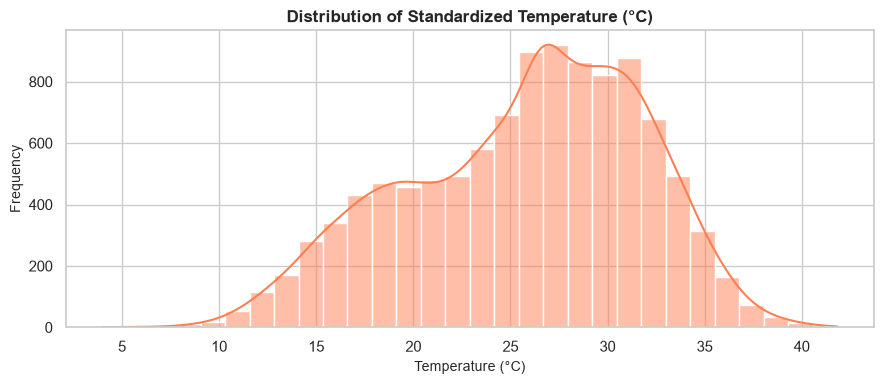

C:\Users\VIDHYA\AppData\Local\Temp\ipykernel_16684\2540627946.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=condition_counts.index, y=condition_counts.values, palette='viridis')


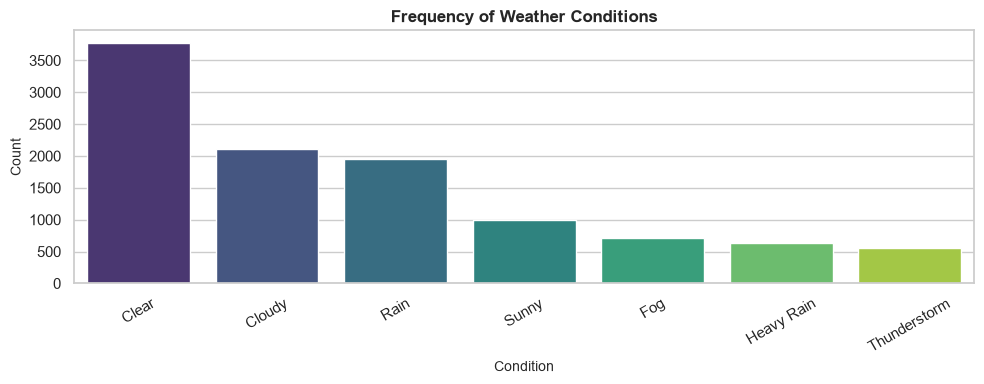

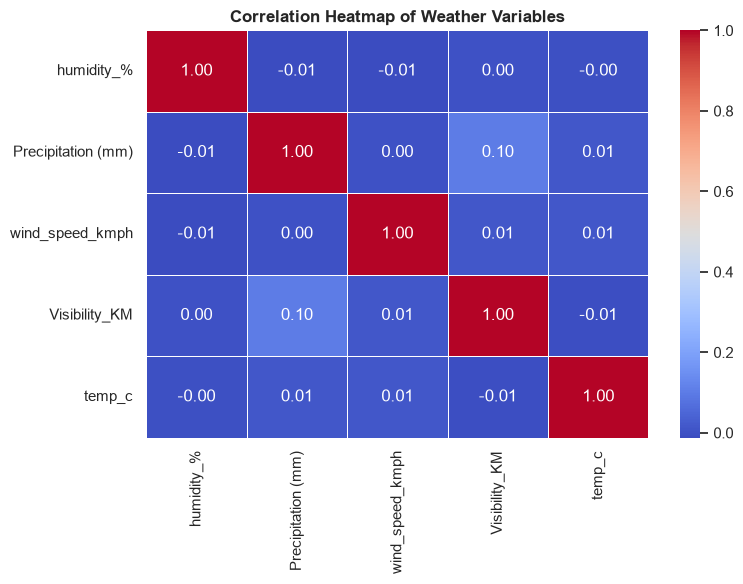

EDA plots generated successfully.


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the fully cleaned dataset
df = pd.read_csv('weather_data_fully_cleaned.csv')

# Basic statistical summary of numerical columns
print(df.describe())

# Generate EDA visualizations
sns.set_theme(style="whitegrid")

# 1. Temperature Distribution (temp_c)
plt.figure(figsize=(9, 4))
sns.histplot(df['temp_c'], kde=True, color='coral', bins=30)
plt.title('Distribution of Standardized Temperature (°C)', fontsize=12, fontweight='bold')
plt.xlabel('Temperature (°C)', fontsize=10)
plt.ylabel('Frequency', fontsize=10)
plt.tight_layout()
plt.show()
plt.close()

# 2. Weather Condition Counts
plt.figure(figsize=(10, 4))
condition_counts = df['condition'].value_counts()
sns.barplot(x=condition_counts.index, y=condition_counts.values, palette='viridis')
plt.title('Frequency of Weather Conditions', fontsize=12, fontweight='bold')
plt.xlabel('Condition', fontsize=10)
plt.ylabel('Count', fontsize=10)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
plt.close()

# 3. Correlation Heatmap of Numerical Features
plt.figure(figsize=(8, 6))
numeric_cols = ['humidity_%', 'Precipitation (mm)', 'wind_speed_kmph', 'Visibility_KM', 'temp_c']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Weather Variables', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
plt.close()

print("EDA plots generated successfully.")